In [2]:
import sys
sys.path.append("../src")
from data_loader import (load_prices, load_returns, compute_hedge_ratio, compute_spread, compute_zscore, generate_signals)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

prices = load_prices()

# reconstruct spreads and signals
beta_MA_V, intercept_MA_V = compute_hedge_ratio(prices, "MA", "V")
beta_GS_MS, intercept_GS_MS = compute_hedge_ratio(prices, "GS", "MS")

spread_MA_V = compute_spread(prices, "MA", "V", beta_MA_V, intercept_MA_V)
spread_GS_MS = compute_spread(prices, "GS", "MS", beta_GS_MS, intercept_GS_MS)

zscore_MA_V = compute_zscore(spread_MA_V)
zscore_GS_MS = compute_zscore(spread_GS_MS)

signals_MA_V = generate_signals(zscore_MA_V)
signals_GS_MS = generate_signals(zscore_GS_MS)

print("Everything loaded.")
print("Signals MA/V:", signals_MA_V.value_counts().to_dict())

Everything loaded.
Signals MA/V: {0: 905, 1: 326, -1: 278}


In [3]:
# When signal = 1 (long spread):
# You are long MA and short V
# If MA goes up and V goes down — you profit
# Daily P&L = return of MA − β × return of V
# When signal = −1 (short spread):
# You are short MA and long V
# Daily P&L = −(return of MA − β × return of V)
# When signal = 0 — P&L = 0, no position.

In [12]:
def compute_pnl(prices , ticker1 , ticker2 , beta , signals , capital = 10000):
    # daily log return for each stock 
    ret_1 = np.log(prices[ticker1] / prices[ticker2].shift(1))
    ret_2 = np.log(prices[ticker2] / prices[ticker2].shift(1))

    # spread return 
    spread_return = ret_1 - beta * ret_2

    # shift signal by 1 - act on nect day 
    signal_shifted = signals.shift(1).fillna(0)

    # daily P&L in dollar terms
    daily_pnl = signal_shifted * spread_return * capital

    return daily_pnl

pnl_MA_V = compute_pnl(prices , "MA" , "V" , beta_MA_V , signals_MA_V)
pnl_GS_MS = compute_pnl(prices , "GS" , "MS" , beta_GS_MS , signals_GS_MS)

print("MA/V P&L stats:")
print(f"  Total P&L : ${pnl_MA_V.sum():.2f}")
print(f"  Mean daily : ${pnl_MA_V.mean():.2f}")
print(f"  Std daily : ${pnl_MA_V.std():.4f}")

MA/V P&L stats:
  Total P&L : $88067.26
  Mean daily : $58.40
  Std daily : $3026.0770


In [5]:
def compute_pnl_with_costs(prices , ticker1 , ticker2 , beta , signals , capital = 10000 , cost_pct = 0.0015):
    # daily log return for each stock 
    ret_1 = np.log(prices[ticker1] / prices[ticker1].shift(1))
    ret_2 = np.log(prices[ticker2] / prices[ticker2].shift(1))

    # spread return 
    spread_return = ret_1 - beta * ret_2

    # shift signal by 1 - act on nect day 
    signal_shifted = signals.shift(1).fillna(0)

    # daily P&L in dollar terms
    daily_pnl = signal_shifted * spread_return * capital
    trade_entry = (signal_shifted != 0) & (signal_shifted.shift(1) == 0)
    trade_exit= (signal_shifted == 0) & (signal_shifted.shift(1) != 0)
    transaction_cost = (trade_entry | trade_exit) * capital * cost_pct

    net_pnl = daily_pnl - transaction_cost

    return net_pnl


pnl_MA_V = compute_pnl_with_costs(prices , "MA" , "V" , beta_MA_V , signals_MA_V) 
pnl_GS_MS = compute_pnl_with_costs(prices, "GS" , "MS" , beta_GS_MS , signals_GS_MS)

print(f"MA/V net pnl : ${pnl_MA_V.sum():.4f}")
print()
print(f"GS/MS net pnl : ${pnl_GS_MS.sum():.4f}")



MA/V net pnl : $5134.2327

GS/MS net pnl : $19023.3585


In [6]:
print("GS/MS daily pnl stats:")
print(f"  Max single day: ${pnl_GS_MS.max():.2f}")
print(f"  Min single day: ${pnl_GS_MS.min():.2f}")
print(f"  Days with pnl != 0: {(pnl_GS_MS != 0).sum()}")

print("\nGS/MS beta:", round(beta_GS_MS, 4))
print("GS price range:", round(prices["GS"].min(), 2), "to", round(prices["GS"].max(), 2))
print("MS price range:", round(prices["MS"].min(), 2), "to", round(prices["MS"].max(), 2))

GS/MS daily pnl stats:
  Max single day: $4325.88
  Min single day: $-4664.99
  Days with pnl != 0: 671

GS/MS beta: 3.3518
GS price range: 116.62 to 377.32
MS price range: 22.92 to 94.53


In [7]:
def compute_pnl_with_costs(prices , ticker1 , ticker2 , beta , signals , capital = 10000 , cost_pct = 0.0015):
    ret_1 = prices[ticker1].pct_change()
    ret_2 = prices[ticker2].pct_change()

    half_capital = capital / 2
    pnl_leg1 = ret_1 * half_capital
    pnl_leg2 = ret_2 * half_capital

    signal_shifted = signals.shift(1).fillna(0)

    daily_pnl = signal_shifted * (pnl_leg1 - pnl_leg2)

    trade_entry = (signal_shifted != 0) & (signal_shifted.shift(1) == 0)
    trade_exit= (signal_shifted == 0) & (signal_shifted.shift(1) != 0)
    transaction_cost = (trade_entry | trade_exit) * capital * cost_pct

    net_pnl = daily_pnl - transaction_cost

    return net_pnl


pnl_MA_V = compute_pnl_with_costs(prices , "MA" , "V" , beta_MA_V , signals_MA_V) 
pnl_GS_MS = compute_pnl_with_costs(prices, "GS" , "MS" , beta_GS_MS , signals_GS_MS)

print(f"MA/V net pnl : ${pnl_MA_V.sum():.4f}")
print()
print(f"GS/MS net pnl : ${pnl_GS_MS.sum():.4f}")
print("\nMA/V max single day  :", f"${pnl_MA_V.max():.2f}")
print("GS/MS max single day :", f"${pnl_GS_MS.max():.2f}")

MA/V net pnl : $1019.4281

GS/MS net pnl : $1205.0691

MA/V max single day  : $198.82
GS/MS max single day : $310.52


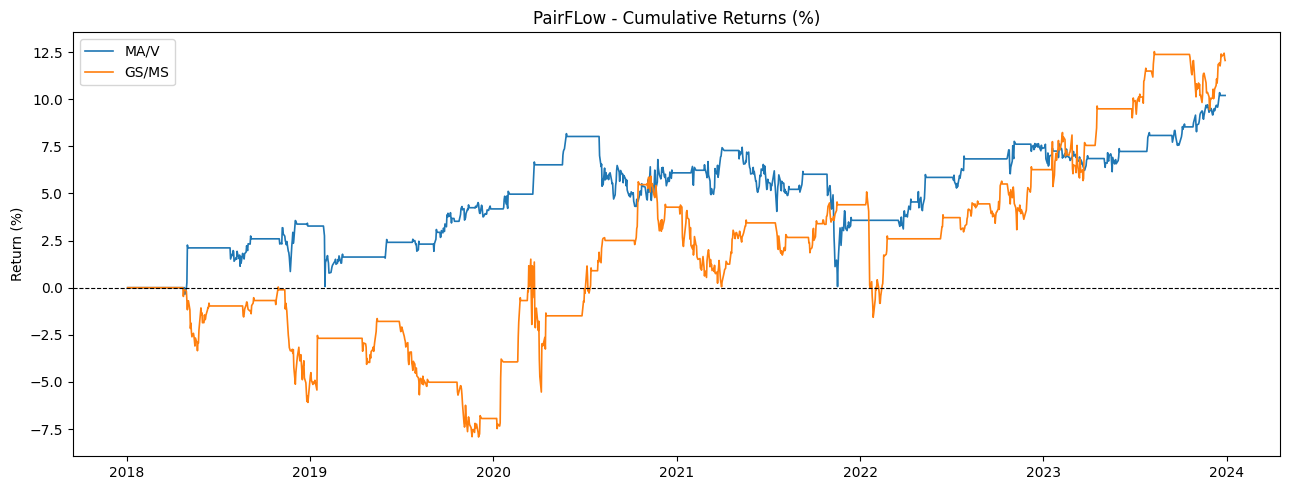

In [8]:
# compute cumulative returns and plot

def plot_cumulative_pnl(pnl_dict , capital = 10000):
    fig, ax = plt.subplots(figsize = (13,5))

    for pair_name , pnl in pnl_dict.items():
        cumulative = pnl.cumsum()
        cumulative_pct = (cumulative / capital) * 100
        ax.plot(pnl.index , cumulative_pct , linewidth = 1.2 , label = pair_name)

    ax.axhline(0,color =  "black" , linewidth = 0.8 , linestyle = "--")
    ax.set_title("PairFLow - Cumulative Returns (%)")
    ax.set_ylabel("Return (%)")
    ax.legend(fontsize =  10)
    plt.tight_layout()
    plt.savefig("../data/cumulative_returns.png" , dpi = 120)
    plt.show()

plot_cumulative_pnl({
    "MA/V" : pnl_MA_V,
    "GS/MS" : pnl_GS_MS
})

Portfolio Stats : 
  Total P&L   : $2224.50
  Mean daily P&L  : $1.4751
  Std daily P&L   : $44.8192


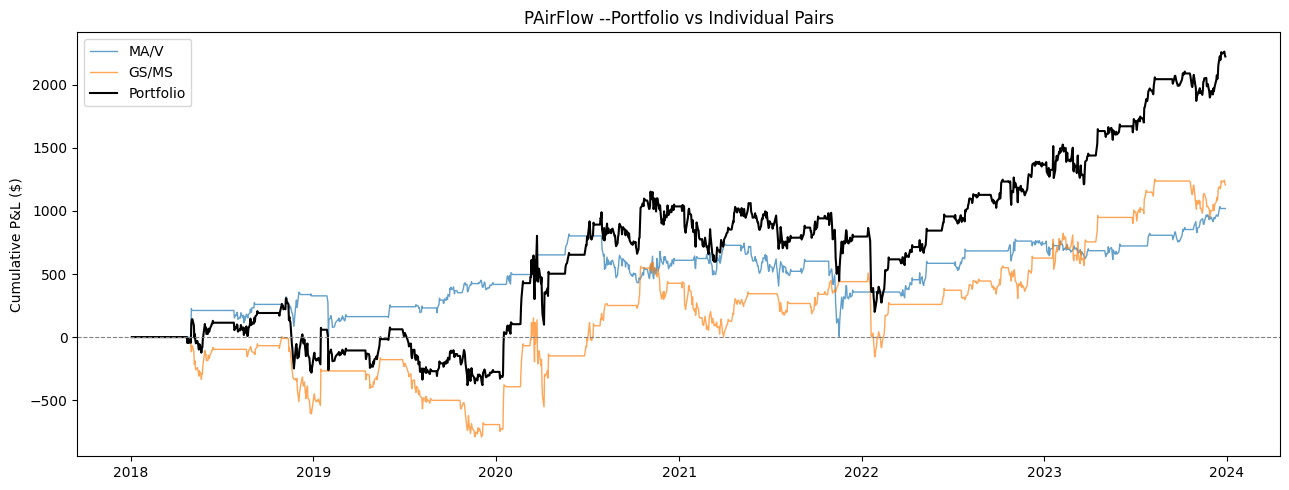

In [9]:
# combined portfolio P&L
portfolio_pnl = pnl_MA_V + pnl_GS_MS

print("Portfolio Stats : ")
print(f"  Total P&L   : ${portfolio_pnl.sum():.2f}")
print(f"  Mean daily P&L  : ${portfolio_pnl.mean():.4f}")
print(f"  Std daily P&L   : ${portfolio_pnl.std():.4f}")

# plot portfolio vs individual pairs 

fig , ax = plt.subplots(figsize = (13,5))

ax.plot(pnl_MA_V.index , pnl_MA_V.cumsum() , linewidth = 1 , label = "MA/V" , alpha = 0.7 )
ax.plot(pnl_GS_MS.index, pnl_GS_MS.cumsum(), linewidth=1, label="GS/MS", alpha=0.7)
ax.plot(portfolio_pnl.index, portfolio_pnl.cumsum(), linewidth=1.5, 
        label="Portfolio", color="black")

ax.axhline(0 ,color = "gray" , linewidth = 0.8 , linestyle = "--")
ax.set_title("PAirFlow --Portfolio vs Individual Pairs")
ax.set_ylabel("Cumulative P&L ($)")
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("../data/portfolio_returns.png", dpi=120)
plt.show()

In [10]:
pnl_df = pd.DataFrame({
    "MA/V" : pnl_MA_V,
    "GS_MS" : pnl_GS_MS,
    "portfolio" : portfolio_pnl
})

pnl_df.to_parquet("../data/pnl.parquet")
verify = pd.read_parquet("../data/pnl.parquet")
print(verify.shape)
print(f"Portfolio total : ${verify['portfolio'].sum():.2f}")


(1509, 3)
Portfolio total : $2224.50


In [11]:
from data_loader import compute_pnl_with_costs

pnl = compute_pnl_with_costs(prices, "MA", "V", beta_MA_V, signals_MA_V)
print(f"MA/V Total P&L: ${pnl.sum():.2f}")

MA/V Total P&L: $1019.43
